# 다중 회귀와 예측 결과 분석

> 여러 입력 변수를 함께 사용해 더 정확한 회귀 모델을 만들고, 예측 결과를 깊이 있게 분석합니다

|구분|입력 변수 개수|예측식|
|---|---|---|
|단순 회귀|1개|`점수 = a x 공부시간 + b`|
|다중 회귀|여러 개|`점수 =a(1) x 공부시간 a(2) x 출석률 + a(3) x 과제 점수 + b`|

-> 각 변수마다 자신의 계수 (coaf,가중치)를 갖고, 모든 항을 더한 뒤 마지막 절편 (interp_)을 더해 예측값을 만든다

# 라이브러리 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## 실습 데이터: 학생 성적 데이터

In [3]:
student_df=pd.DataFrame({
    "study_hours":[1,2,3,4,5],
    "attendance":[10,20,30,40,50],
    "assignment":[10,20,30,40,50],
    "scores":[60,70,80,90,100],
})

student_df.head()

,study_hours,attendance,assignment,scores
0,1,10,10,60
1,2,20,20,70
2,3,30,30,80
3,4,40,40,90
4,5,50,50,100


## 데이터 살펴보기

In [4]:
student_df.describe()

,study_hours,attendance,assignment,scores
count,5.000000,5.000000,5.000000,5.000000
mean,3.000000,30.000000,30.000000,80.000000
std,1.581139,15.811388,15.811388,15.811388
min,1.000000,10.000000,10.000000,60.000000
25%,2.000000,20.000000,20.000000,70.000000
50%,3.000000,30.000000,30.000000,80.000000
75%,4.000000,40.000000,40.000000,90.000000
max,5.000000,50.000000,50.000000,100.000000


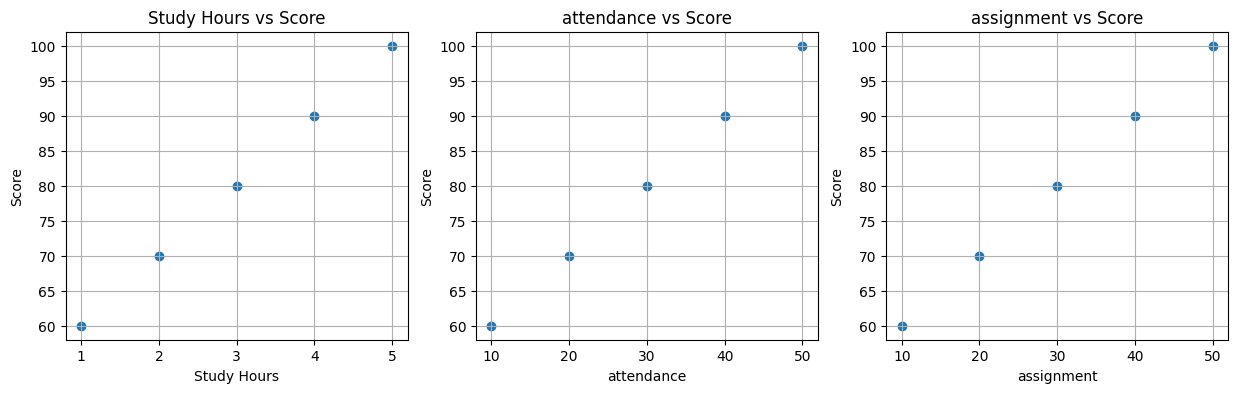

In [9]:
fig, axes=plt.subplots(1,3,figsize=(15,4))

axes[0].scatter(student_df["study_hours"],student_df["scores"])
axes[0].set_title("Study Hours vs Score")
axes[0].set_xlabel("Study Hours")
axes[0].set_ylabel("Score")
axes[0].grid(True)

axes[1].scatter(student_df["attendance"],student_df["scores"])
axes[1].set_title("attendance vs Score")
axes[1].set_xlabel("attendance")
axes[1].set_ylabel("Score")
axes[1].grid(True)

axes[2].scatter(student_df["assignment"],student_df["scores"])
axes[2].set_title("assignment vs Score")
axes[2].set_xlabel("assignment")
axes[2].set_ylabel("Score")
axes[2].grid(True)

## 단순 회귀 모델 만들기 (비교용 베이스라인)

다중 회귀와 성능을 비교할 때 기준점(baseline)으로 사용

In [11]:
X = student_df[['study_hours']]
y = student_df['scores']

print("X모양",X.shape)
print("y모양",y.shape)

X모양 (5, 1)
y모양 (5,)


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

print("훈련데이터 계수",len(X_train))
print("테스트 데이터 계수",len(y_train))

model=LinearRegression()
model.fit(X_train,y_train)

print("모델 학습 완료")
print(f"기울기:${model.coef_[0]:.3f}")
print(f"절편:${model.intercept_[0]:.3f}")

pred=model.predict(X_test)
print("예측완료")

훈련데이터 계수 3
테스트 데이터 계수 3
모델 학습 완료
기울기:$10.000


IndexError: invalid index to scalar variable.

## 다중 회귀 모델 학습하기

In [17]:
X_multi=student_df[['study_hours','attendance','assignment']]
y_multi=student_df['scores']

print("X_multi 모임",X_multi.shape)
print("y_multi 모임",y_multi.shape)

X_train_m,X_test_m,y_train_m,y_test_m=train_test_split(
    X_multi,y_multi,
    test_size=0.3,
    random_state=42
)

multi_model=LinearRegression()
multi_model.fit(X_train_m,y_train_m)

print("다중 회귀 모델 학습 완료")

X_multi 모임 (5, 3)
y_multi 모임 (5,)
다중 회귀 모델 학습 완료


## 다중 회귀 모델의 계수 해석하기

예측 점수 =  a(1) x study_hours <br>
            + a(2) x attendance<br>
            + a(3) x assignment<br>
            + b(절편)<br>
a(1), a(2), a(3) 은 각 변수의 계수(coef_), `b`는 절편(intercept_)

각 계수의 의미: 다른 변수가 모두 그대로일 때, 해당 변수가 1만큼 증가하면서 예측 점수가 계수 만큼 변한다.

단, 변수마다 단위가 다르므로 **계수의 절댓값만 보고 변수이 중요도를 비교하면 안된다**

In [23]:
coef_df=pd.DataFrame({
    'feature': X_multi.columns,
    'coef':multi_model.coef_,
})

print(f"절편:{multi_model.intercept_:.3f}")
coef_df

절편:50.000


,feature,coef
0,study_hours,0.049751
1,attendance,0.497512
2,assignment,0.497512


- `study_hours`의 계수가 양수이면, 공부시간 1시간 늘어날 때 예측 점수가 그만큼 올라간다는 뜻
- `attendance`의 계수가 양수이면, 출석률 1%p 늘어날때 예측 점수가 그만큼 올라간다는 뜻
- `assignment`의 계수가 양수이면, 과제 점수 1점 늘어날 때 예측 점수가 그만큼 올라간다는 뜻

만약 어떤 계수가 **음수** 라면 그 변수가 커질수록 예측값은 작아진다


## 문제

위에서 얻은 계수와 절편을 이용해, 다음 학생의 예측 점수를 계산한다
- `study_hours`=6
- `attendance`=80
- `assignment`=75

예측 점수= <br>
        study_hours 계수 x 6<br>
            + attendance 계수 x 80<br>
            + assignment 계수 x 75<br>
            + 절편

## 단순 회귀 vs 다중 회귀 성능 비교

- `MAE` : 평균적으로 몇 점 차이로 들리는가(작을수록 좋음)
- `R제곱`:모델이 점수의 변화를 얼마나 잘 설명 하는가(1에 가까울수록 좋음)


In [30]:
#다중 회귀 예측
multi_pred=multi_model.predict(X_test_m)

#단순 회귀 평가
simple_mae=mean_absolute_error(y_test.pred)
simple_r2=r2_score(y_test_m,mulit_pred)

compare_df=pd.DataFrame({
    'model':['study_hours only','study_hours + attendance + assignment'],
    'MAE':[simple_mae,mulit_mae],
    'R2':[simple_r2,mulit_r2]
})

compare_df

AttributeError: 'Series' object has no attribute 'pred'

결과 해석

- 다중 회귀의 `MAE`가 단순 회귀보다 훨씬 작다 -> 평균 오차가 더 작다는 뜻
- 다중 회귀의 `R2`가 단순 회귀보다 1에 가깝다 -> 데이터의 패턴을 더 잘 설명한다는 뜻

이는 **출석률** 과 **과제 점수** 가 단순히 "공부시간 으로는 설명되지 않는 추가정보"를 모델에 제공했기 때문입니다

> **주의** - 변수를 무조건 많으 넣는다고 항상 좋아지지는 않습니다. 의미 없는 변수가 들어오면 오히려 Noise가 늘어나 성능이 떨어지거나(과적합) 결과 해석이 어려워질 수 있습니다 머신러닝 과목에서 `변수 선택(feture selection)` 으로 깊이 다룹니다